**House Prices:**
Kaggle midterm project

Student:Linah Taha

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
%matplotlib inline


In [166]:
data=pd.read_csv("train.csv")
print("shape:",data.shape)
print(data.head(5))

shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [167]:
#predict
print("SalePrice:")
print(data["SalePrice"].value_counts().head(10)) #counts diffrent outputs 


SalePrice:
SalePrice
140000    20
135000    17
155000    14
145000    14
190000    13
110000    13
115000    12
160000    12
130000    11
139000    11
Name: count, dtype: int64


**Data Quality & Missing Data:**
Before building model I need to Identify and handle any missing Values.

In [168]:
missing=data.isnull().sum().sort_values(ascending=False)
missing_percent=(missing/len(data))*100
missing_df=pd.DataFrame({"Missing Count": missing, "percent": missing_percent})
print("Colums with missing values:")
print(missing_df[missing_df['Missing Count']>0].to_string())

Colums with missing values:
              Missing Count    percent
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageYrBlt              81   5.547945
GarageCond               81   5.547945
GarageType               81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


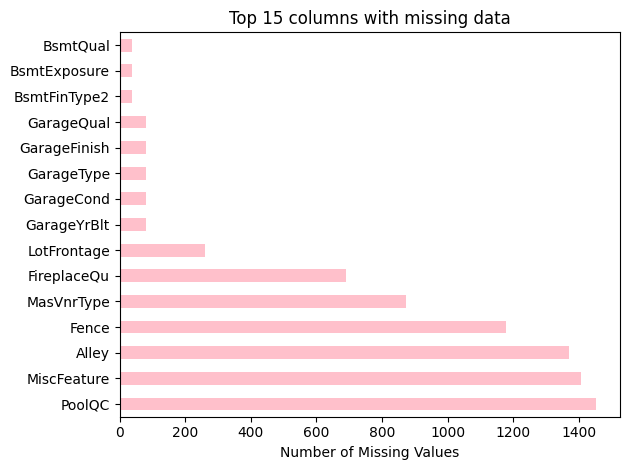

In [169]:
MostMissing=missing[missing>0].head(15)
MostMissing.plot(kind='barh', title="Top 15 columns with missing data", color="pink")
plt.xlabel("Number of Missing Values")
plt.tight_layout()
plt.show()

Columns liek PoolQC, MiscFeature and Alley have the largest amount of missig data. For numerical values we can use the median to fill in the missing data

**Feature Engineering:** Inorder to make the features stronger I combined related features

    TotalSF = 1stFlrSF+ 2ndFlrSF+ TotalBsmtSF
    TotalSF is the total space of the house intead of teh orginal individual floors
    
    HouseAge = YrSold - YearBuilt 
    gives actual age instead of just a year number
    
    RemodalAge = YrSold - YearRemodAdd 
    how long ago the remodel happened
    
    TotalBath = FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath 
    all bathroom value
    
    TotalPorchSF= WoodDeckSF + OpenPorchSF + EnclosedPorch + ScreenPorch 
    total outdoor space

    premium=Quality x Size interaction - big house + high quality
    high Quality and a larger house 
    
    Hasgarage=using binary 
    absence of garbage 
    
    Hasbasement=binary
    absence of basement
    
    Haspool=binary
    absence of pool 

    LotToLivRatio=Price per square foot-lot size relative to living area
    A large lot with a small house is different value than a large house on a small lot


In [170]:
data=data.fillna(data.median(numeric_only=True))
print("Missing numerical values after impuation:",data.select_dtypes(include=[np.number]).isnull().sum().sum())

Missing numerical values after impuation: 0


**Outliers**

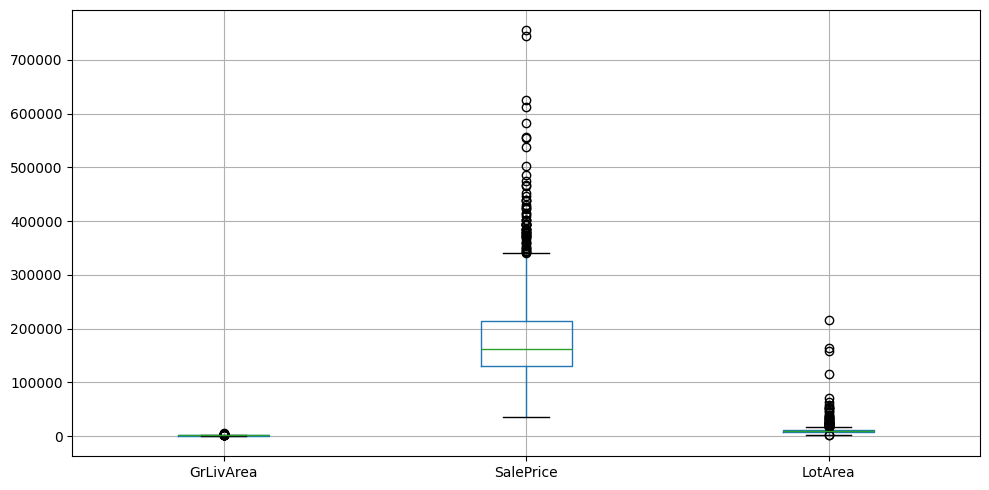

After outliers removed: (1454, 81)


In [171]:
#Visualize outliers 
data.boxplot(column=['GrLivArea', 'SalePrice', 'LotArea'], figsize=(10,5))
plt.tight_layout()
plt.show()

#remove outliers
data=data[data['GrLivArea']<4000]
data=data[data['SalePrice']<600000]
print("After outliers removed:", data.shape)

In [172]:
data['TotalSF'] = data['1stFlrSF'] + data['2ndFlrSF'] + data['TotalBsmtSF']
data['HouseAge']=data['YrSold']-data['YearBuilt']
data['RemodalAge']=data['YrSold']-data['YearRemodAdd']
data['TotalBath'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
data['TotalPorchSF']=data['WoodDeckSF']+data['OpenPorchSF'] + data['EnclosedPorch'] + data['ScreenPorch']

#5 new features 
data['premium'] = data['OverallQual'] * data['TotalSF']
data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
data['HasBasement'] = (data['TotalBsmtSF'] > 0).astype(int)
data['HasPool'] = (data['PoolArea'] > 0).astype(int)
data['LotToLivRatio'] = data['LotArea'] / data['GrLivArea']


In [173]:

features = ['TotalSF','HouseAge','RemodalAge','TotalBath','TotalPorchSF',
            'OverallQual','GrLivArea','GarageCars','GarageArea','TotRmsAbvGrd',
            'GarageYrBlt','WoodDeckSF','MasVnrArea','Fireplaces','LotFrontage',
            'premium','HasGarage','HasBasement','HasPool','LotToLivRatio']
target = 'SalePrice'

df=data[features+[target]].copy()
print("Shape:",df.shape)

X=df[features]
Y=df[target]

print("Shape of x:",X.shape)
print("Shape of Y:",Y.shape)

Shape: (1454, 21)
Shape of x: (1454, 20)
Shape of Y: (1454,)


**Feature selection based on correlation of SalesPrice:**
Inorder to figure out which feature matter the most for predicting SalesPrice, I measuring the correlation between each numerical feature and the SalePrice. Correlation ranges from -1 to 1, the closer the correlation to 1 the stronger the feature.Therefore any correlation above 0.5 shows a strong realtionship between that feature and the SalesPrice. 

In [174]:
#LabelEncoder misleads currlation method bec of of arbritary numbers it assigns 
#grab numerical features only
numerical_ft= data.select_dtypes(include=[np.number]).columns
           #corrlation table of [the features we care abt].drop corrlation with its self(1 corrlation )
correlation=data[numerical_ft].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print(correlation.head(10))


premium        0.913055
TotalSF        0.823612
OverallQual    0.802905
GrLivArea      0.718257
GarageCars     0.652263
TotalBsmtSF    0.643758
GarageArea     0.639948
TotalBath      0.634594
1stFlrSF       0.622381
FullBath       0.559606
Name: SalePrice, dtype: float64


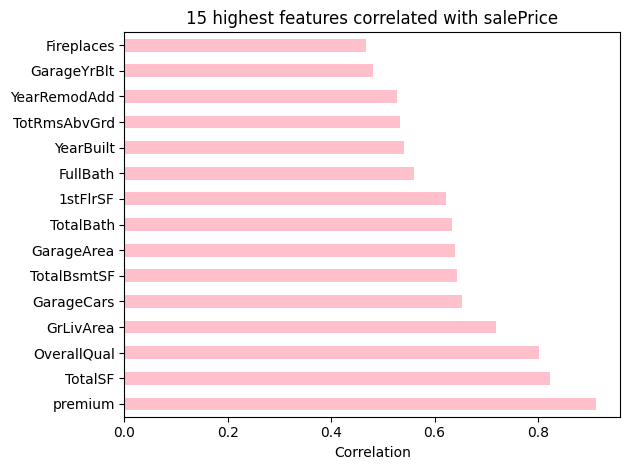

In [175]:
correlation.head(15).plot(kind='barh', title='15 highest features correlated with salePrice',color="pink")
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

**Feature importance:** My reason for picking certain features was due to the correlation. I then trained a Random Forest all 15 features to provide me with the top 10 highest ranked important features.

In [176]:
#from sklearn.tree import DecisionTreeClassifier classifyier for yes/no need int values = regression
from sklearn.ensemble import RandomForestRegressor

#Train random Forest to rank which features matter (DT:use 100 trees and avg )
rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X,Y)

importance=pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("importance rank:")
print(importance.head(10))



importance rank:
premium          0.847566
RemodalAge       0.019528
HouseAge         0.014379
LotToLivRatio    0.014179
GarageArea       0.014085
TotalBath        0.013031
TotalSF          0.011366
GrLivArea        0.010472
GarageYrBlt      0.009619
TotalPorchSF     0.009092
dtype: float64


In [177]:
top_ft=importance.head(10).index.tolist() #pull out 10 features from df to use elsewhere
X=data[top_ft]
Y=data[target]

from sklearn.model_selection import train_test_split
X_train,X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=42)
print(f"Training:{len(X_train)} and Testing:{len(X_test)}")

Training:1163 and Testing:291


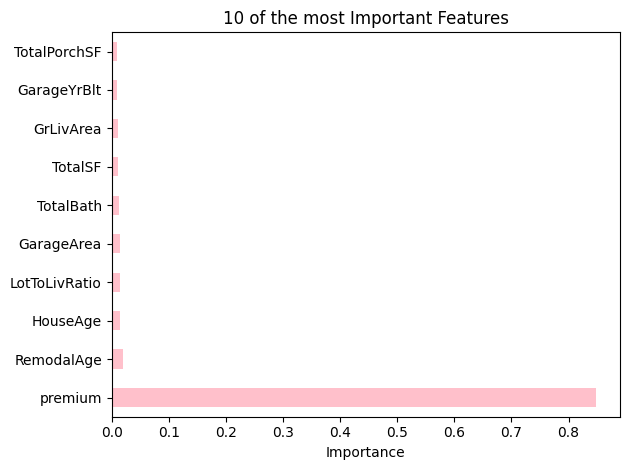

In [178]:
importance.head(10).plot(kind='barh', title='10 of the most Important Features', color="pink")
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Model 1:** Decision Tree splits data into brances based on value of the feature.Each split tries to group houses with similar prices together.

In [179]:
#from sklearn.tree import DecisionTreeClassifier classifyier for yes/no need int values = regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train, Y_train)
dt_pred=dt.predict(X_test)

print("Decision Tree")
print(f"R^2 Score: {r2_score(Y_test, dt_pred):.4f}") #how well model prediction matches the real values(close to 1)
print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, dt_pred)):.2f}")#how far predictions are from real value on avg(small)


Decision Tree
R^2 Score: 0.6744
RMSE:41909.05


Decision Tree Improved->limit the depth and stop overfitting

In [180]:
                         #how many levels of tree can grow,min number of saples in node before it can split
dt2=DecisionTreeRegressor(max_depth=8, min_samples_split=10, random_state=42)
dt2.fit(X_train, Y_train)
dt2_pred=dt2.predict(X_test)

print("Decision Tree Improved")
print(f"R^2 Score: {r2_score(Y_test, dt2_pred):.4f}") #how well model prediction matches the real values(close to 1)
print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, dt2_pred)):.2f}")#how far predictions are from real value on avg(small)


Decision Tree Improved
R^2 Score: 0.7164
RMSE:39118.08


**Model 2:** KNN predicts a house's price by finding the 5 closest neighors houses in the training data and averaging their prices.


In [181]:
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.preprocessing import StandardScaler 

knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, Y_train)
knn_pred=knn.predict(X_test)

print("KNN")
print(f"R^2 Score: {r2_score(Y_test, knn_pred):.4f}")
print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, knn_pred)):.2f}")


KNN
R^2 Score: 0.8218
RMSE:31006.85


KNN Improved- Becasue features like GarageArea have such a wide range (0-1400) as apposed to TotalBath(0-4) the range becomes an unfair bias.Scaling allows for all the features to be on the same scale. Futhermore I tuned k inorder to find a cloaser prediction.

In [182]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

knn2=KNeighborsRegressor(n_neighbors=10)
knn2.fit(X_train_scaled,Y_train)
knn2_pred=knn2.predict(X_test_scaled)

print("KNN Improved")
print(f"R^2 Score: {r2_score(Y_test, knn2_pred):.4f}")
print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, knn2_pred)):.2f}")


KNN Improved
R^2 Score: 0.8661
RMSE:26874.55


**Model 3:** SVR fits a line through the data and tries to keep most predictions within a margin of the actual prices.

In [183]:
from sklearn.svm import SVR

svr=SVR(kernel='linear')
svr.fit(X_train_scaled, Y_train)
svr_pred=svr.predict(X_test_scaled)


print("SVR")
print(f"R^2 Score: {r2_score(Y_test, svr_pred):.4f}")
print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, svr_pred)):.2f}")


SVR
R^2 Score: 0.0791
RMSE:70486.32


SVM improved-A straight line can't capture the complex relationships in housing data. Switching to the RBF kernel lets the model fit curves instead. I also increased C to 10000 which makes the model try harder to reduce errors.

In [184]:
#how to draw the curve, C:how strick model is abt erros, gamma:how much the model focuses a each traing point (bigpiture/details)
svr2=SVR(kernel='rbf', C=10000, gamma='scale')
svr2.fit(X_train_scaled, Y_train)
svr2_pred=svr2.predict(X_test_scaled)

print("SVR Improved")
print(f"R^2 Score: {r2_score(Y_test, svr2_pred):.4f}")
print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, svr2_pred)):.2f}")



SVR Improved
R^2 Score: 0.8604
RMSE:27444.88


**Random Forest Regressor Model**

In [185]:
rf1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf1.fit(X_train, Y_train)
rf_pred=rf1.predict(X_test)

print("Random Forest")
print(f"R^2 Score:{r2_score(Y_test, rf_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, rf_pred)):.4f}")

Random Forest
R^2 Score:0.8552
RMSE: 27947.0188


Tuned:

In [186]:
rf2 = RandomForestRegressor(n_estimators=250, random_state=42)
rf2.fit(X_train, Y_train)
rf_pred2=rf2.predict(X_test)

print("Random Forest")
print(f"R^2 Score:{r2_score(Y_test, rf_pred2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, rf_pred2)):.4f}")

Random Forest
R^2 Score:0.8573
RMSE: 27746.7226


How RF compares with orginal features vs new engineered ones:

To measure the diffrence between the orginal features and the featured engineered ones, I first trained RF on the fully engineered features then on the orginal features. It is evident that the engineering features improved both R^2 and RMSE

In [187]:
#Rf with the orginal features=baseline 
rf_original=['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotRmsAbvGrd']
X_org=data[rf_original]
X_train_org, X_test_org, Y_train_org, Y_test_org = train_test_split(X_org, Y, test_size=0.2, random_state=42) 

rf_org=RandomForestRegressor(n_estimators=100, random_state=42)
rf_org.fit(X_train_org, Y_train_org)
rf_org_pred=rf_org.predict(X_test_org)

print("RF - Original Features")
print(f"R^2: {r2_score(Y_test_org, rf_org_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test_org, rf_org_pred)):.2f}")



RF - Original Features
R^2: 0.8111
RMSE: 31926.60


**Model Comparison**
Comparing all 6 models (3 baselines + 3 improved) side by side. R^2 (closer to 1 is better) and RMSE (lower is better). Every model improved after tuning, with RF (tuned)performing the best overall.

In [188]:
tabel=pd.DataFrame({
    'Model':['Decision Tree', 'Decision Tree (Tuned)', 'KNN', 'KNN (Scaled & K adjustment)', 'SVR(Linear)', 'SVR(RBF)', 'RF', 'RF tuned'],
    'R^2':[r2_score(Y_test, dt_pred), r2_score(Y_test, dt2_pred),
           r2_score(Y_test, knn_pred), r2_score(Y_test, knn2_pred),
           r2_score(Y_test, svr_pred), r2_score(Y_test, svr2_pred),r2_score(Y_test, rf_pred),r2_score(Y_test, rf_pred2)], 
    'RMSE':[np.sqrt(mean_squared_error(Y_test, dt_pred)), 
            np.sqrt(mean_squared_error(Y_test, dt2_pred)),
            np.sqrt(mean_squared_error(Y_test, knn_pred)), 
            np.sqrt(mean_squared_error(Y_test, knn2_pred)),
            np.sqrt(mean_squared_error(Y_test, svr_pred)), 
            np.sqrt(mean_squared_error(Y_test, svr2_pred)), np.sqrt(mean_squared_error(Y_test, rf_pred)), np.sqrt(mean_squared_error(Y_test, rf_pred2))]
})
print(tabel.sort_values('R^2', ascending=False).to_string(index=False)) #sort so that highst r^2 is on the top

                      Model      R^2         RMSE
KNN (Scaled & K adjustment) 0.866124 26874.552534
                   SVR(RBF) 0.860382 27444.879083
                   RF tuned 0.857294 27746.722645
                         RF 0.855226 27947.018760
                        KNN 0.821789 31006.847128
      Decision Tree (Tuned) 0.716355 39118.083261
              Decision Tree 0.674436 41909.049695
                SVR(Linear) 0.079063 70486.318469


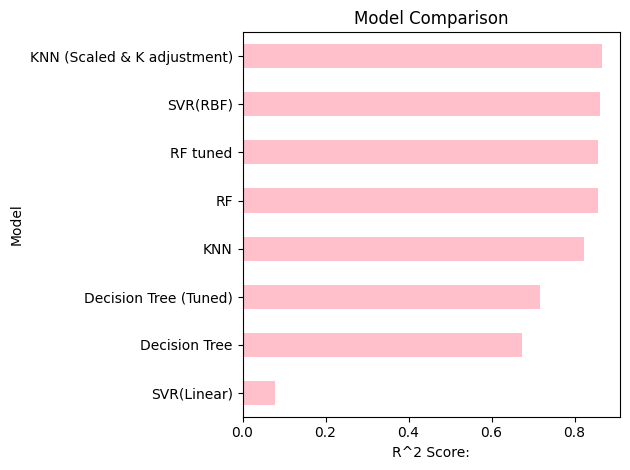

In [189]:
tabel.sort_values('R^2', ascending=True).plot(kind='barh',x="Model", y='R^2', title='Model Comparison', legend=False, color="pink")
plt.xlabel('R^2 Score:')
plt.tight_layout()
plt.show()

**SHAP**

In [192]:
!pip install shap --ignore-installed --no-deps

  Using cached shap-0.51.0-cp312-cp312-win_amd64.whl.metadata (26 kB)
Using cached shap-0.51.0-cp312-cp312-win_amd64.whl (556 kB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\linah\\anaconda3\\Lib\\site-packages\\_kernel_lib.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



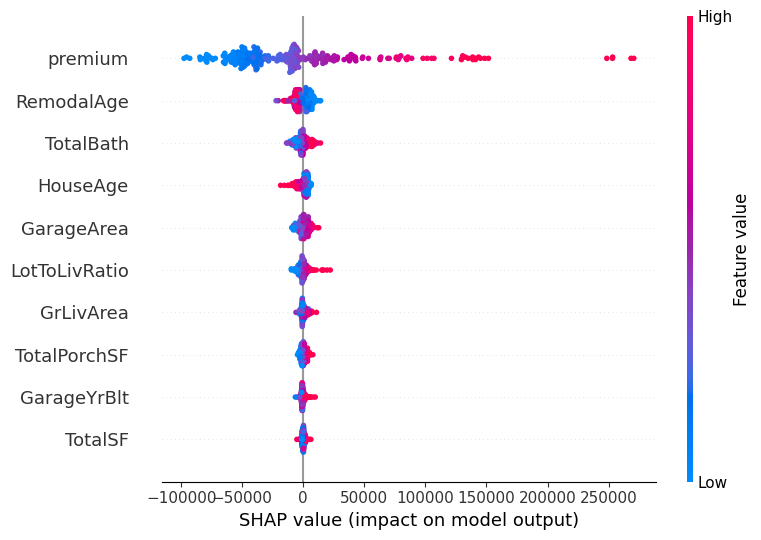

In [191]:
import shap
box=shap.TreeExplainer(rf2)
shap_values=box.shap_values(X_test)

shap.summary_plot(shap_values,X_test)

**Conclusion**

RF with feature tuning to n_estimator=250 was the best model with an R^2 of 0.81. TotalSF and OverallQual with feature importance making up over 88% of the Random Forest's importance scores.Every model improved after tuning. 